# Demo 01: Echogram fu
### `themachinethatgoesping` tutorial series

Here we show how to create echograms from acoustic data and how to do magic with them

In [1]:
%matplotlib widget
%gui qt

import numpy as np
import themachinethatgoesping as theping
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from collections import defaultdict

import os

QColorSpace attempted constructed from invalid primaries: QPointF(0.313477,0.329102) QPointF(0.691406,0.318359) QPointF(0.266602,0.682617) QPointF(0.151367,0.0585938)


# Open Datasets

In [5]:
# data folder
folder = r'/home/users/data/SSPIRIT/data/sspirit_03/'
folder = '/home/users/data/no_backup/GEOMAR/Meteor-M143/MBES/M143_EM710_raw/'
map_path = r'/home/users/data/SSPIRIT/map/BPNS_latlon.tiff'

all_pings_by_channel = {}
theping.pingprocessing.core.clear_memory()

In [6]:
# find all Kongsberg files in the list of folders
files = sorted(theping.echosounders.index_functions.find_files(folder,['.all', '.wcd']))
cache_files = theping.echosounders.index_functions.get_index_paths(files)

# create the file handler
fh_mbes = theping.echosounders.kongsbergall.KongsbergAllFileHandler(files, cache_files)

# get pings that contain WCD
pings_mbes = theping.pingprocessing.filter_pings.by_features(fh_mbes.get_pings(),['watercolumn.amplitudes'])

# split pings by channel and add to pings_by_channel
all_pings_by_channel.update(theping.pingprocessing.split_pings.by_channel_id(pings_mbes))

Found 435 files
indexing files ⠁ 99% :01s<00m:00s] [Found: 5966116 datagrams in 435 files (52495MB)]                                                 
Initializing ping interface ⠐ 99% :07s<00m:00s] [Done]                                                                             


In [5]:
# find all Kongsberg files in the list of folders
files = sorted(theping.echosounders.index_functions.find_files(folder,['.all', '.wcd']))
cache_files = theping.echosounders.index_functions.get_index_paths(files)
files

Found 435 files


['/home/users/data/no_backup/GEOMAR/Meteor-M143/MBES/M143_EM710_raw/0000_20171212_160314_M143_EM710.all',
 '/home/users/data/no_backup/GEOMAR/Meteor-M143/MBES/M143_EM710_raw/0000_20171212_160314_M143_EM710.wcd',
 '/home/users/data/no_backup/GEOMAR/Meteor-M143/MBES/M143_EM710_raw/0001_20171212_160604_M143_EM710.all',
 '/home/users/data/no_backup/GEOMAR/Meteor-M143/MBES/M143_EM710_raw/0001_20171212_160604_M143_EM710.wcd',
 '/home/users/data/no_backup/GEOMAR/Meteor-M143/MBES/M143_EM710_raw/0002_20171212_161758_M143_EM710.all',
 '/home/users/data/no_backup/GEOMAR/Meteor-M143/MBES/M143_EM710_raw/0003_20171212_161804_M143_EM710.all',
 '/home/users/data/no_backup/GEOMAR/Meteor-M143/MBES/M143_EM710_raw/0003_20171212_161804_M143_EM710.wcd',
 '/home/users/data/no_backup/GEOMAR/Meteor-M143/MBES/M143_EM710_raw/0004_20171212_164804_M143_EM710.all',
 '/home/users/data/no_backup/GEOMAR/Meteor-M143/MBES/M143_EM710_raw/0004_20171212_164804_M143_EM710.wcd',
 '/home/users/data/no_backup/GEOMAR/Meteor-M14

## EM2040

In [22]:
# find all Kongsberg files in the list of folders
files = sorted(theping.echosounders.index_functions.find_files(folder,['.kmall', '.kmwcd']))
cache_files = theping.echosounders.index_functions.get_index_paths(files)

# create the file handler
fh_mbes = theping.echosounders.kmall.KMALLFileHandler(files[2:4], cache_files)

# get pings that contain WCD
pings_mbes = theping.pingprocessing.filter_pings.by_features(fh_mbes.get_pings(),['watercolumn.amplitudes'])

# split pings by channel and add to pings_by_channel
all_pings_by_channel.update(theping.pingprocessing.split_pings.by_channel_id(pings_mbes))

NameError: name 'folder' is not defined

In [8]:
pingviewer = theping.widgets.WCIViewerQt(pings_mbes)

In [15]:
ping = pings_mbes[pingviewer.panel['ping_slider_0'].value]
av = ping.watercolumn.get_av().flatten()
avb = av.copy()
avb.shape

(65536,)

In [14]:
avb = np.ones(521*1000)

In [15]:
%%timeit
#avb = av.copy()
theping.tools.math.fma_dispatch(avb, 12., 13.)

141 μs ± 633 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [16]:
%%timeit
#avb = av.copy()
theping.tools.math.fma_xtensor(avb, 12., 13.)

141 μs ± 667 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [17]:
%%timeit
avb * 12. + 13.

392 μs ± 17.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [57]:
print(pingviewer.pings[0].watercolumn.get_tx_signal_parameters()[0])

CWSignalParameters
##################
- center_frequency:         320.000e³     [Hz]
- bandwidth:                19.949e³      [Hz]
- effective_pulse_duration: 46.050e⁻⁶     [s]


In [58]:
#show keys in all_pings_by_channel
base_key = next(iter(all_pings_by_channel.keys()))
all_pings_by_channel.keys(), base_key

(dict_keys(['TRX-5003']), 'TRX-5003')

# Get overview

In [59]:
#use this transducer to create 'stations'

#split data when there is more than 60 seconds between two pings
pings_per_station = theping.pingprocessing.split_pings.by_time_difference(all_pings_by_channel[base_key], 36000)
pings_per_station.keys()

dict_keys([0])

plotting overview for pings: Done    


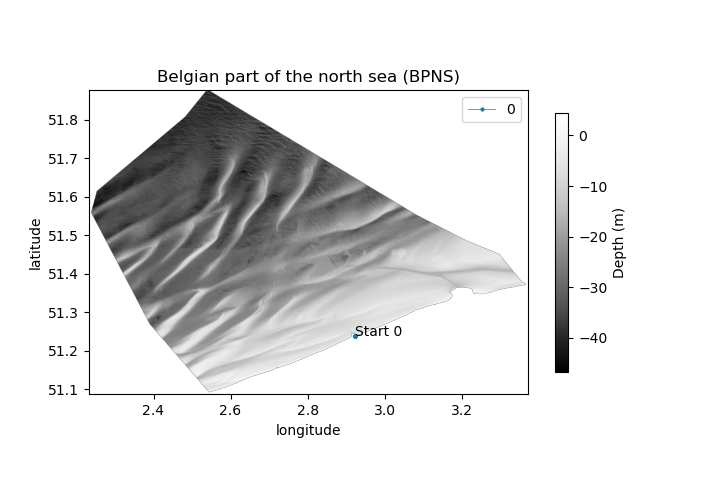

In [60]:
fig, ax = theping.pingprocessing.overview.nav_plot.create_figure(
#fig, ax = create_figure(
    "Belgian part of the north sea (BPNS)", 
    aspect="equal", 
    background_image_path=map_path, 
    background_colorbar_label='Depth (m)',
    colorbar_orientation='vertical',
    add_grid=False,
    cmap="Greys_r"
)

stats = theping.pingprocessing.overview.get_ping_overview(pings_per_station)

for k,v in stats.items():
    v.plot_navigation(ax, label=k)

print(f"plotting overview for pings: Done    ")
ax.legend()

fig.set_figwidth(3.34646) #85mm
fig.set_figwidth(7.08661) #180mm


In [61]:
stations = [0]

pings = []
for s in stations:
    pings.extend(pings_per_station[s])

pings_per_freq = defaultdict(list)
for ping in pings:
    tx = ping.watercolumn.get_tx_signal_parameters()
    pings_per_freq[tx[0].get_center_frequency()].append(ping)

for k,v in list(pings_per_freq.items()):
    #print(k,len(v))
    if len(v) < 10:
        print(f'del({k},{len(v)}')
        del(pings_per_freq[k])

print()
for k,v in list(pings_per_freq.items()):
    print(k,len(v))


320000.0 1799
190000.0 1799
260000.0 1798
680000.0 1150
550000.0 92


# create echograms from the data

In [62]:
echogram_data = {}

# for multibeam data only stack beams between -3 and +3° beam angle
pss = theping.echosounders.pingtools.PingSampleSelector()
pss.select_beam_range_by_angles(-3,3)

# go through all channels and create an echogram builder for the channel
for k in reversed(sorted(pings_per_freq.keys())):
    
    echogram_data[k] = theping.pingprocessing.watercolumn.echograms.EchogramBuilder.from_pings(
        pings_per_freq[k],
        pss=pss,
        wci_value = 'sv/av/pv/rv',
        linear_mean=False,
        verbose=False)


#set minslant parameter
for k,e in tqdm(echogram_data.items()):
    e.set_x_axis_date_time(max_steps=200000)
    e.set_y_axis_depth()

  0%|          | 0/5 [00:00<?, ?it/s]

# Display echogram using echogram viewer

In [63]:
pings_per_freq.keys()

dict_keys([320000.0, 190000.0, 260000.0, 680000.0, 550000.0])

In [105]:
pingviewer = theping.widgets.WCIViewerPyQtGraph(pings_per_freq[190000.0])
echogramviewer.connect_pingviewer(pingviewer)

RFBOutputContext()

In [ ]:
pingviewer.wci_value_override()

In [100]:
from functools import partial
def get_wci(ping, selection):
    d = ping.file_data.datagrams("#MRZ")[0] 
    power = d.ping_info.get_tx_power_db()
    vals  = ping.watercolumn.get_av(selection)
    vals  -= power
    return vals
pingviewer.wci_value_override = get_wci

In [106]:
ping1 = pingviewer.pings[1510]
ping2 = pingviewer.pings[1520]

d1 = ping1.file_data.datagrams("#MRZ")[0]
d2 = ping2.file_data.datagrams("#MRZ")[0]
print(d1.ping_info.get_tx_power_db())
print(d2.ping_info.get_tx_power_db())
d1.ping_info.get_fixed_gain_control(),d2.ping_info.get_fixed_gain_control()
#d1.tx_sectors[0].print()
#d2.tx_sectors[0].print()
np.nanmean(d1.soundings.get_receiver_sensitivity_applied_db_tensor()),np.nanmean(d2.soundings.get_receiver_sensitivity_applied_db_tensor())

-0.0
-0.0


(np.float32(-195.18268), np.float32(-195.1656))

In [68]:
echogramviewer = theping.widgets.EchogramViewer(echogram_data)
echogramviewer.connect_pingviewer(pingviewer)

# Read and process CSV file as layer

In [32]:
#set ctd depth offset
import pandas as pd

csv_data = pd.read_csv(os.path.join(folder,'csv/ST2227_SBE09_2.csv'))
print(csv_data.iloc[0:5]['DepSM'])
                       
ctd_depth_offset = 0.8 #will be added
ctd_depth_offset = 2

0   -0.737
1   -0.793
2   -0.713
3   -0.737
4   -0.737
Name: DepSM, dtype: float64


In [33]:
#read ctd table
csv_data = pd.read_csv(os.path.join(folder,'csv/ST2227_SBE09_2.csv'))
csv_data['Datetime'] = pd.to_datetime(csv_data['Datetime'],utc=True, dayfirst=True)
csv_data = csv_data.set_index('Datetime')
csv_data['DepSM'] += ctd_depth_offset # depth offset ctd
#csv_data


In [34]:
#create table with only numeric data, resample to 1second and add as layer to the echograms
data_vals = csv_data.copy()
del data_vals['Vessel']
del data_vals['Plume']
del data_vals['Activity']
data_vals = data_vals[data_vals['DepSM'] > 0]
data_vals = data_vals.resample('1s').mean().dropna()

for e in echogramviewer.echogramdata:
    e.clear_layers()
    e.add_layer('ctd',data_vals.index, data_vals['DepSM']-0.5,data_vals['DepSM']+0.5)

#data_vals
#you can now press update in the echogramviewer

In [35]:
#extract average from echograms

from collections import defaultdict
import datetime
import pandas as pd

T= defaultdict(list)
V= defaultdict(list)
W= defaultdict(list)
data = defaultdict(pd.DataFrame)
for i,e in enumerate(tqdm(echogramviewer.echogramdata)):
    name = echogramviewer.names[i]
    try:
        for p in tqdm(list(e.iterate_ping_data(True))):
            e0,e1 = p.get_extent_layers()['ctd']
            l0,l1 = p.get_limits_layers()['ctd']
            if e0 == e1:
                continue
        
            T[name].append(datetime.datetime.fromtimestamp(p.get_ping_time(), tz=datetime.timezone.utc))
            wci = p.get_wci_layers_range_stack()['ctd']
            V[name].append(wci)
            W[name].append(np.mean(wci))
    except:
        pass

    data[name]['time'] = pd.to_datetime(T[name])
    data[name][f'mean sv - {name}'] = W[name]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1322 [00:00<?, ?it/s]

  0%|          | 0/1060 [00:00<?, ?it/s]

/ssd/src/themachinethatgoesping/tutorials/.pixi/envs/default/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: >

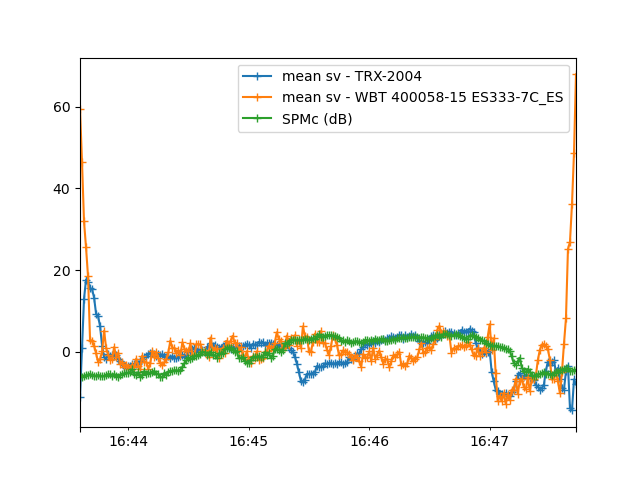

In [38]:
# merge data and plot
time_step = '1s'

merged_df = []
for name,d in data.items():
    merged_df.append(data[name].set_index('time').resample(time_step).mean())

data_vals = csv_data.copy()
data_vals = data_vals[data_vals['DepSM'] > 0]
data_vals = data_vals[['SPMc']]
data_vals['SPMc (dB)']=10*np.log10(data_vals['SPMc'])
data_vals = data_vals.resample(time_step).mean().dropna()
merged_df.append(data_vals)

merged_df_ = merged_df
merged_df = []
for df in merged_df_:
    if len(df) >0:
        merged_df.append(df)

merged_df = pd.concat(merged_df,axis=1).dropna()

merged_df_ = merged_df.copy()
del merged_df_['SPMc']
for k in merged_df_.keys():
    merged_df_[k]-=np.nanmedian(merged_df_[k])


merged_df_.plot(marker='+')

In [37]:
merged_df.to_csv(f'station({station})-layer-averages.csv')

In [ ]:
#merged_df

In [ ]:
import datetime

#modify max_depth if necessary
max_depth = 30 #m
time_resolution = 1 #s (subsampled not averaged)

#take min/max from merged_df
t0 = merged_df.index[0] - datetime.timedelta(minutes=5)
t1 = merged_df.index[-1] + datetime.timedelta(minutes=5)

In [ ]:
import importlib
import functions.util as util
importlib.reload(util)

#set minslant parameter
for k,e in tqdm(echogram_data.items()):
    #set maximum resolution
    e.set_x_axis_date_time(max_steps=100000,time_resolution=time_resolution, min_ping_time=t0.timestamp(), max_ping_time=t1.timestamp())
    e.set_y_axis_depth(max_steps=51200, max_depth=max_depth)

    # create image
    image, extent = e.build_image(progress=True)
    xim = util.image_to_xarray(image,extent,xdim='Ping time', ydim='Depth(m)')
    
    xim.to_netcdf(f'station({station})-{k}.nc', format='NETCDF4', engine="netcdf4")
    
    e.set_x_axis_date_time(max_steps=4000)
    e.set_y_axis_depth(max_steps=512, max_depth=30)

In [ ]:
t1-t0